<a href="https://colab.research.google.com/github/321222/Adventure_game/blob/main/Sales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib .pyplot as plt
from sklearn.preprocessing import MinMaxScaler
sns.set_style("whitegrid")


In [2]:
df=pd.read_csv('AusApparalSales4thQrt2020.csv')
df.head()

,Date,Time,State,Group,Unit,Sales
0,1-Oct-2020,Morning,WA,Kids,8,20000
1,1-Oct-2020,Morning,WA,Men,8,20000
2,1-Oct-2020,Morning,WA,Women,4,10000
3,1-Oct-2020,Morning,WA,Seniors,15,37500
4,1-Oct-2020,Afternoon,WA,Kids,3,7500


In [5]:
df.info()
df.describe()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7560 entries, 0 to 7559
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Date    7560 non-null   object
 1   Time    7560 non-null   object
 2   State   7560 non-null   object
 3   Group   7560 non-null   object
 4   Unit    7560 non-null   int64 
 5   Sales   7560 non-null   int64 
dtypes: int64(2), object(4)
memory usage: 354.5+ KB


Index(['Date', 'Time', 'State', 'Group', 'Unit', 'Sales'], dtype='object')

In [11]:
df.isna().sum()

,0
Date,0
Time,0
State,0
Group,0
Unit,0
Sales,0


In [13]:
df.dropna(inplace=True)

In [15]:
scaler=MinMaxScaler()
df[['Sales','Unit']]=scaler.fit_transform(df[['Sales','Unit']])
df.head()

,Date,Time,State,Group,Unit,Sales
0,1-Oct-2020,Morning,WA,Kids,0.095238,0.095238
1,1-Oct-2020,Morning,WA,Men,0.095238,0.095238
2,1-Oct-2020,Morning,WA,Women,0.031746,0.031746
3,1-Oct-2020,Morning,WA,Seniors,0.206349,0.206349
4,1-Oct-2020,Afternoon,WA,Kids,0.015873,0.015873


In [19]:
print("Mean:\n", df[['Sales','Unit']].mean())
print("Median:\n", df[['Sales','Unit']].median())
print("Std:\n", df[['Sales','Unit']].std())
print("Mode:\n", df[['Sales','Unit']].mode())

Mean:
 Sales    0.254054
Unit     0.254054
dtype: float64
Median:
 Sales    0.190476
Unit     0.190476
dtype: float64
Std:
 Sales    0.204784
Unit     0.204784
dtype: float64
Mode:
       Sales      Unit
0  0.111111  0.111111


In [21]:
state_sale= df.groupby('State')['Sales'].sum().sort_values(ascending=False)
print(state_sale)

State
VIC    635.968254
NSW    441.714286
SA     339.412698
QLD    177.888889
TAS    110.222222
NT     109.079365
WA     106.365079
Name: Sales, dtype: float64


In [22]:
group_sale=df.groupby('Group')['Sales'].sum().sort_values(ascending=False)
print(group_sale)

Group
Men        484.444444
Women      482.492063
Kids       480.142857
Seniors    473.571429
Name: Sales, dtype: float64


In [24]:
print("Highest  sales state:", state_sale.idxmax())
print("Lowest sales state :", state_sale.idxmin())
print("Highest sales group::", group_sale.idxmax())
print("Lowest sales group:", group_sale.idxmin())

Highest  sales state:  VIC
Lowest sales state :  WA
Highest sales group::  Men
Lowest sales group:  Seniors


In [25]:
from ipywidgets.widgets.trait_types import Date
df['Date']=pd.to_datetime(df['Date'])
weekly_sale= df.resample('W', on='Date')['Sales'].sum()
monthly_sale= df.resample('M', on='Date')['Sales'].sum()
quaterly_sale= df.resample('Q', on='Date')['Sales'].sum()
print(weekly_sale.head())
print(monthly_sale.head())
print(quaterly_sale.head())

Date
2020-10-04     84.857143
2020-10-11    152.777778
2020-10-18    150.476190
2020-10-25    151.587302
2020-11-01    122.460317
Freq: W-SUN, Name: Sales, dtype: float64
Date
2020-10-31    645.650794
2020-11-30    495.761905
2020-12-31    779.238095
Freq: ME, Name: Sales, dtype: float64
Date
2020-12-31    1920.650794
Freq: QE-DEC, Name: Sales, dtype: float64


/tmp/ipykernel_11786/1766485406.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sale= df.resample('M', on='Date')['Sales'].sum()
/tmp/ipykernel_11786/1766485406.py:5: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  quaterly_sale= df.resample('Q', on='Date')['Sales'].sum()


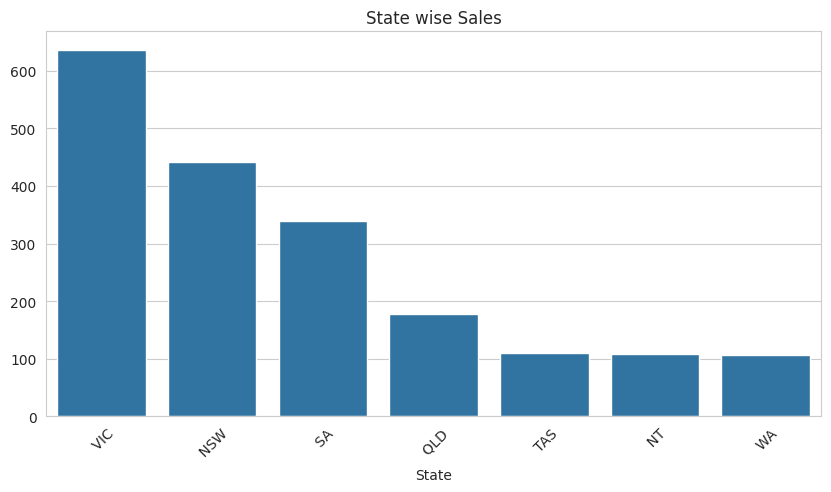

In [31]:
plt.figure(figsize=(10,5))
sns.barplot(x=state_sale.index, y=state_sale.values)
plt.title('State wise Sales')
plt.xticks(rotation=45)
plt.show()

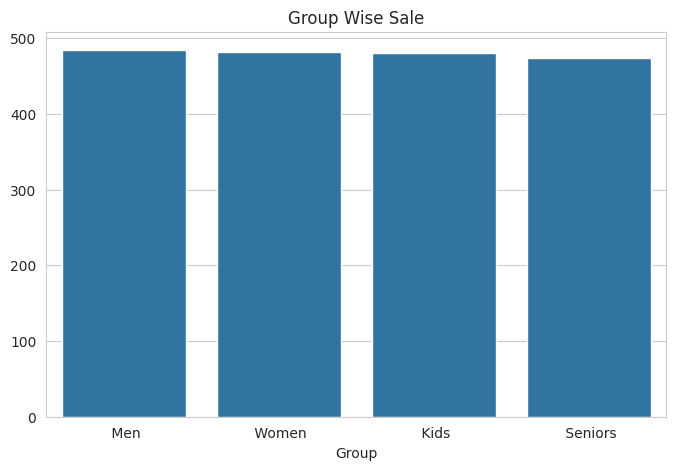

In [33]:
plt.figure(figsize=(8,5))
sns.barplot(x=group_sale.index, y=group_sale.values)
plt.title('Group Wise Sale')
plt.show()

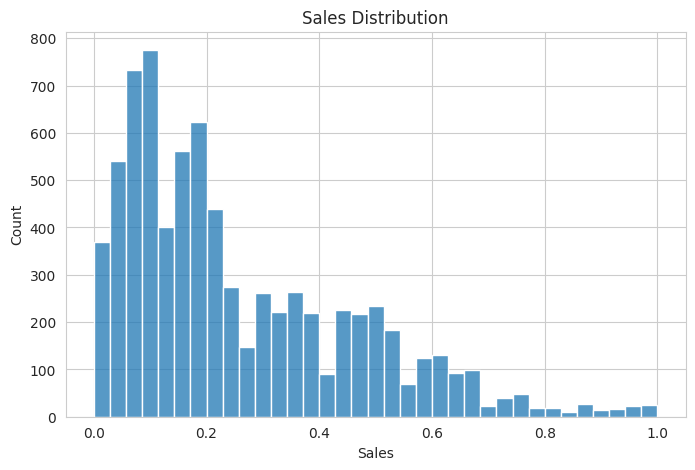

In [35]:
plt.figure(figsize=(8,5))
sns.histplot(df['Sales'])
plt.title('Sales Distribution')
plt.show()

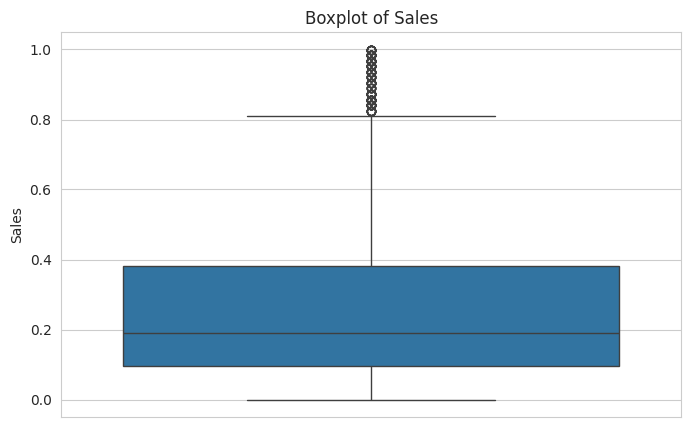

In [36]:
plt.figure(figsize=(8,5))
sns.boxplot(df['Sales'])
plt.title("Boxplot of Sales")
plt.show()

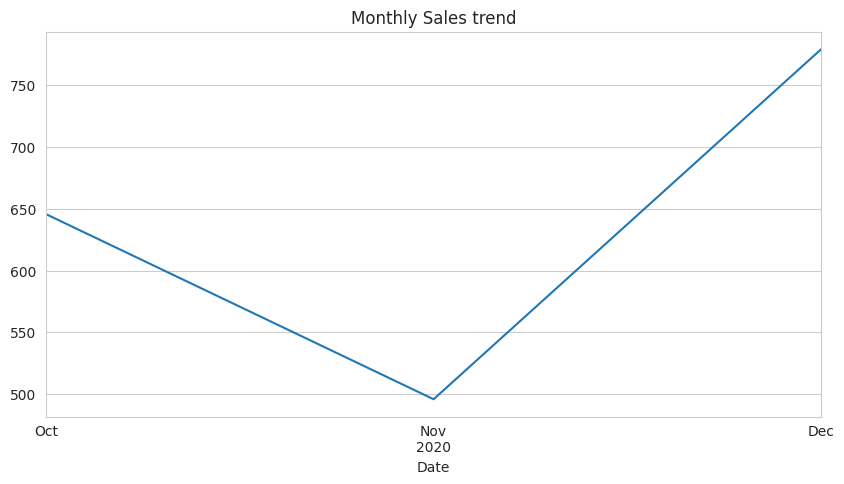

In [38]:
plt.figure(figsize=(10,5))
monthly_sale.plot()
plt.title("Monthly Sales trend")
plt.show()

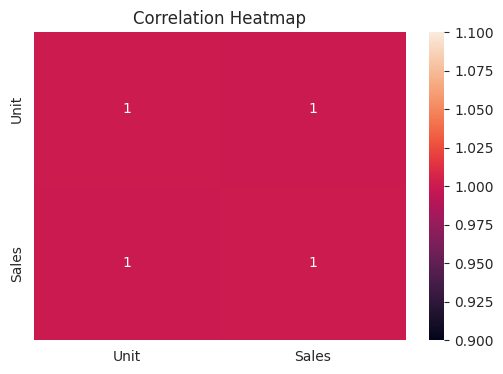

In [40]:
plt.figure(figsize=(6,4))
sns.heatmap(df[['Unit', 'Sales']].corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()